In [1]:
import os
import torch
import time, datetime
from torch.autograd import Variable
from torch import optim
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from datasets import load_dataset
import nest_asyncio; nest_asyncio.apply()
import matplotlib.pyplot as plt
import random
import numpy as np

# Imposta il seed per tutti i moduli
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

# Per CUDA
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # se usi più GPU

# Migliora la determinazione del comportamento
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


/home/ngng/miniconda3/envs/DLENV/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
class VGG(nn.Module):
    def __init__(self, pool='avg'):
        super(VGG, self).__init__()
        #vgg modules
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv3_3 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv3_4 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv4_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv4_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv4_4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_1 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.conv5_4 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        if pool == 'max':
            self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool5 = nn.MaxPool2d(kernel_size=2, stride=2)
        elif pool == 'avg':
            self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool3 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool4 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool5 = nn.AvgPool2d(kernel_size=2, stride=2)

    def forward(self, x, out_keys):
        out = {}
        out['r11'] = F.relu(self.conv1_1(x))
        out['r12'] = F.relu(self.conv1_2(out['r11']))
        out['p1'] = self.pool1(out['r12'])
        out['r21'] = F.relu(self.conv2_1(out['p1']))
        out['r22'] = F.relu(self.conv2_2(out['r21']))
        out['p2'] = self.pool2(out['r22'])
        out['r31'] = F.relu(self.conv3_1(out['p2']))
        out['r32'] = F.relu(self.conv3_2(out['r31']))
        out['r33'] = F.relu(self.conv3_3(out['r32']))
        out['r34'] = F.relu(self.conv3_4(out['r33']))
        out['p3'] = self.pool3(out['r34'])
        out['r41'] = F.relu(self.conv4_1(out['p3']))
        out['r42'] = F.relu(self.conv4_2(out['r41']))
        out['r43'] = F.relu(self.conv4_3(out['r42']))
        out['r44'] = F.relu(self.conv4_4(out['r43']))
        out['p4'] = self.pool4(out['r44'])
        out['r51'] = F.relu(self.conv5_1(out['p4']))
        out['r52'] = F.relu(self.conv5_2(out['r51']))
        out['r53'] = F.relu(self.conv5_3(out['r52']))
        out['r54'] = F.relu(self.conv5_4(out['r53']))
        out['p5'] = self.pool5(out['r54'])
        return [out[key] for key in out_keys]

class GramMatrix(nn.Module):
    def forward(self, input):
        b,c,h,w = input.size()
        F = input.view(b, c, h*w)
        G = torch.bmm(F, F.transpose(1,2))
        G.div_(h*w)
        return G

class GramMSELoss(nn.Module):
    def forward(self, input, target):
        out = nn.MSELoss()(GramMatrix()(input), target)
        return(out)
    
class PearsonCorrelationLoss(nn.Module):
    def forward(self, x, y):
        """
        Pearson correlation loss.
        """
        
        x_gram = GramMatrix()(x)

        x_flat = x_gram.view(-1).float()
        y_flat = y.view(-1).float()

        mean_x = torch.mean(x_flat)
        mean_y = torch.mean(y_flat)

        xm = x_flat - mean_x
        ym = y_flat - mean_y

        numer = torch.dot(xm, ym)
        denom = torch.sqrt(torch.dot(xm, xm) * torch.dot(ym, ym))
        eps = 1e-8
        r = numer / (denom + eps)
        distance = 1.0 - r
        return (distance)

class CosineSimilarityLoss(nn.Module):
    def forward(self, x, y):
        """
        Cosine similarity loss.
        """
        x_gram = GramMatrix()(x)

        x_flat = x_gram.view(-1).float()
        y_flat = y.view(-1).float()
        # Dot‐product
        dot_xy = torch.dot(x_flat, y_flat)
        # Norme L2
        norm_x = torch.norm(x_flat, p=2)
        norm_y = torch.norm(y_flat, p=2)
        eps = 1e-8
        cos_sim = dot_xy / (norm_x * norm_y + eps)
        return (1.0 - cos_sim)

In [3]:
# pre and post processing for images
img_size = 512
prep = transforms.Compose([transforms.Resize(img_size),
                           transforms.ToTensor(),
                           transforms.Lambda(lambda x: x[torch.LongTensor([2,1,0])]), #turn to BGR
                           transforms.Normalize(mean=[0.40760392, 0.45795686, 0.48501961], #subtract imagenet mean
                                                std=[1,1,1]),
                           transforms.Lambda(lambda x: x.mul_(255)),
                          ])
postpa = transforms.Compose([transforms.Lambda(lambda x: x.mul_(1./255)),
                           transforms.Normalize(mean=[-0.40760392, -0.45795686, -0.48501961], #add imagenet mean
                                                std=[1,1,1]),
                           transforms.Lambda(lambda x: x[torch.LongTensor([2,1,0])]), #turn to RGB
                           ])
postpb = transforms.Compose([transforms.ToPILImage()])

def postp(tensor): # to clip results in the range [0,1]
    t = postpa(tensor)
    t[t>1] = 1
    t[t<0] = 0
    img = postpb(t)
    return img

#############################
# Loading VGG-19 Weights
#############################

model_dir = './model_dir/'

vgg = VGG()
vgg.load_state_dict(torch.load(model_dir + 'vgg_conv.pth'))

<All keys matched successfully>

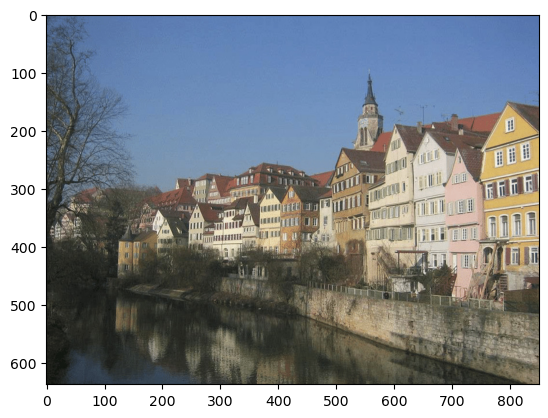

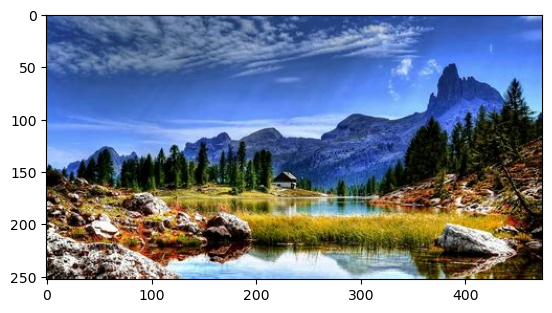

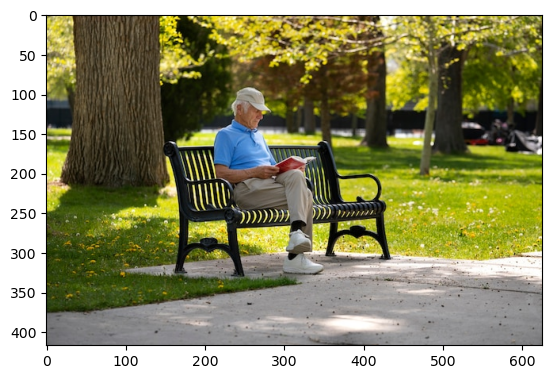

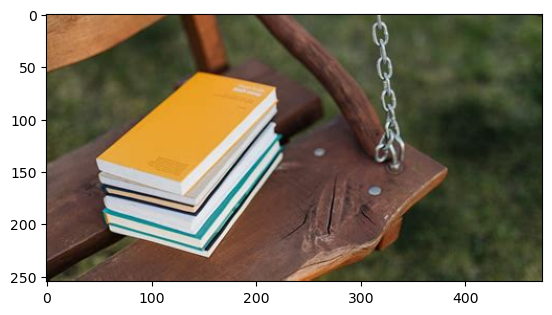

In [4]:
for param in vgg.parameters():
    param.requires_grad = False
if torch.cuda.is_available():
    vgg.cuda()


#############################################
# Content and Style Images, Output Directory
#############################################

content_dir = './content/'
style_dir = './style/'
output_dir = './output/'

content_imgs = [Image.open(os.path.join(content_dir, f)) for f in os.listdir(content_dir) if f.endswith('.jpg')]
for img in content_imgs:
    plt.imshow(img);
    plt.show()
content_imgs = [Variable(prep(img).unsqueeze(0).cuda()) for img in content_imgs]


Style images: 6


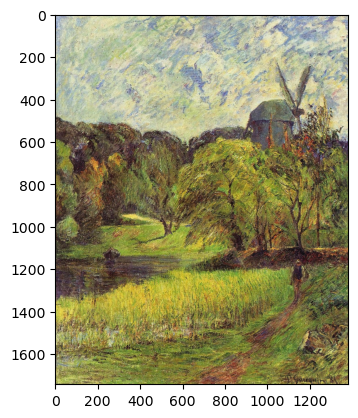

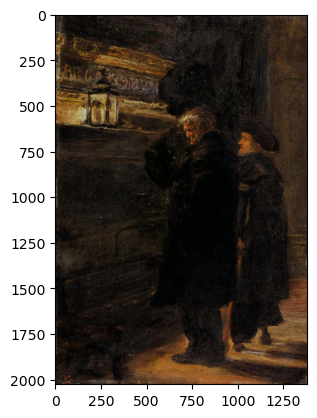

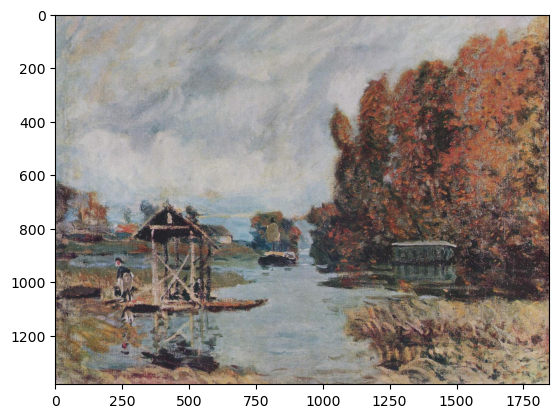

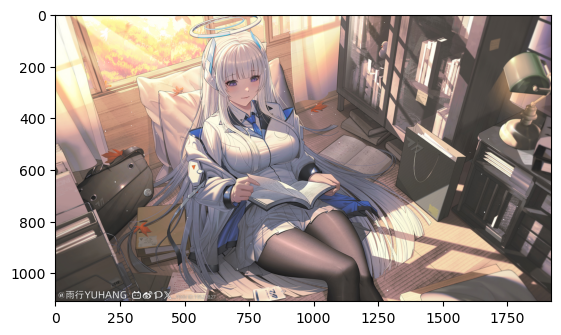

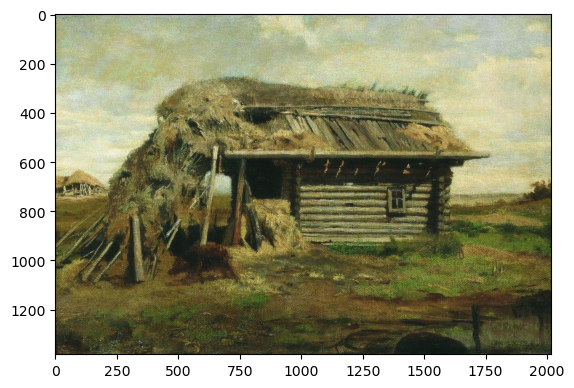

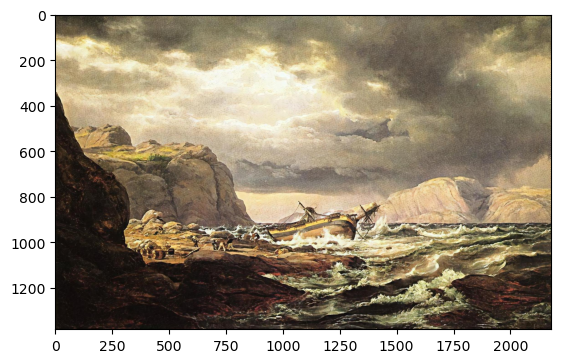

In [5]:
style_imgs = [Image.open(os.path.join(style_dir, f)) for f in os.listdir(style_dir) if f.endswith('.jpg')]
print(f"Style images: {len(style_imgs)}")

for img in style_imgs:
    plt.imshow(img)
    plt.show()
style_imgs = [Variable(prep(img).unsqueeze(0).cuda()) for img in style_imgs]

In [6]:
#%pip install lion-pytorch
#%pip install torch-optimizer

In [ ]:


def synthesizeImage3(style_image, content_image, loss_fn, 
                     style_weights, content_weights, max_iter=500, 
                     show_iter=100, threshold=1e-4,
                     lr=1.75,
                     ini_image = None):

    # Image to optimize is a clone of the content image for faster convergence
    if ini_image is None:
        opt_img = Variable(content_image.data.clone(), requires_grad=True)
    else:
        opt_img = Variable(ini_image.data.clone(), requires_grad=True)
        #opt_img = ini_image
    prev_img = opt_img.data.clone()  # per norma max

    style_layers = ['r11','r21','r31','r41', 'r51']
    content_layers = ['r42']
    loss_layers = style_layers + content_layers

    # Loss functions (MSE, Pearson, etc.)
    loss_fns = [loss_fn()] * len(style_layers) + [nn.MSELoss()] * len(content_layers)
    if torch.cuda.is_available():
        loss_fns = [loss_fn.cuda() for loss_fn in loss_fns]

    weights = style_weights + content_weights

    # Compute optimization targets
    style_targets = [GramMatrix()(A).detach() for A in vgg(style_image, style_layers)]
    content_targets = [A.detach() for A in vgg(content_image, content_layers)]
    targets = style_targets + content_targets

    optimizer = optim.LBFGS([opt_img], lr=lr)  # LBFGS as in Gatys
    n_iter = [0]

    stop_flag = [False]  # segnale di arresto

    while n_iter[0] <= max_iter and not stop_flag[0]:

        def closure():
            optimizer.zero_grad()
            out = vgg(opt_img, loss_layers)
            layer_losses = [weights[a] * loss_fns[a](A, targets[a]) for a,A in enumerate(out)]
            loss = torch.sum(torch.stack(layer_losses))
            loss.backward()

            # 🧮 Calcolo delta max (norma infinito degli aggiornamenti)
            delta = (opt_img.data - prev_img).abs()
            delta_norm = torch.max(delta).item()
            if delta_norm < threshold and n_iter[0] > 75:
            #    for param_group in optimizer.param_groups:
            #        print(f"⏹️ Early stopping: Δ = {delta_norm:.3f} < {threshold}, Iteration {n_iter[0]}: Loss = {loss.item()}, Current LR: {np.round(param_group['lr'],3)}")
                #print(f"⏹️ Early stopping: Δ = {delta_norm:.3f} < {threshold}, Iteration {n_iter[0]}: Loss = {loss.item()}")
                stop_flag[0] = True

            prev_img.copy_(opt_img.data)  # aggiornamento per prossimo confronto

            n_iter[0] += 1
            #if n_iter[0] % show_iter == 0:
            #    for param_group in optimizer.param_groups:
            #        print(f"Iteration {n_iter[0]}: Current LR: {np.round(param_group['lr'],3)}, Loss = {loss.item()} | Δ = {delta_norm:.6f}")
            return loss

        optimizer.step(closure)

    return postp(opt_img.data[0].cpu().squeeze())



In [8]:



def compute_ratio_style_weights(vgg, 
                                content_img, 
                                style_img, 
                                style_layers, 
                                content_layers, 
                                style_loss_fn,
                                style_loss_weight = 1/3,  # Peso relativo della style loss rispetto alla content loss
                                verbose = False,
                                weight_channel_aware=True):  
    """
    Calcola i pesi relativi per ciascun livello di stile in una rete di style transfer.

    L'obiettivo è bilanciare la style loss rispetto alla content loss, assegnando a ogni livello
    di stile un peso proporzionale alla sua importanza e alla sua risposta. Questo permette di
    ottenere uno stile più coerente e controllato durante l'ottimizzazione.

    Args:
        vgg (callable): Funzione o modello che estrae le feature maps da un'immagine.
        content_img (Tensor): Immagine di contenuto (batch_size x 3 x H x W).
        style_img (Tensor): Immagine di stile (batch_size x 3 x H x W).
        style_layers (list): Indici o nomi dei layer da cui estrarre le feature di stile.
        content_layers (list): Indici o nomi dei layer da cui estrarre le feature di contenuto.
        style_loss_fn (callable): Funzione di loss da usare per confrontare le feature di stile.
                                  Può essere GramMSELoss o una funzione personalizzata.
        style_loss_weight (float, optional): Fattore di bilanciamento tra style e content loss.
                                             Default = 1/3.
        verbose (bool, optional): Se True, stampa dettagli intermedi per debugging.

    Returns:
        scaled_style_weights (list of float): Pesi normalizzati per ciascun livello di stile.
        rmse_content_weights (list of float): Pesi per la content loss (attualmente fissi).
    """
  
    import torch.nn as nn

    rmse_content_weights = [1.0]
    eps = 1e-9
    layer_channels = [64, 128, 256, 512, 512]

    # Estrai feature maps
    content_feats = vgg(content_img, content_layers)
    style_feats = vgg(style_img, style_layers)

    # Content loss con feature fittizie costanti
    content_loss = 0.0
    for feat in content_feats:
        mean_val = feat.mean()
        fake_feat = torch.full_like(feat, mean_val)
        content_loss += nn.MSELoss()(feat, fake_feat)
    #if verbose:
    #    print(f"loss contenuto mse: {content_loss.item():.3e}")    

    # Style loss per livello
    style_losses = []

    for feat in style_feats:
        gram = GramMatrix()(feat)
        # Calcola la deviazione standard per ogni canale
        channel_std = feat.std(dim=(2, 3), keepdim=True)
        ##b, c, h, w = feat.size()
        ##channel_means = feat.mean(dim=(2, 3), keepdim=True)
        ###std = feat.mean() * 0.05
        ##noise = torch.randn_like(feat) * std
        ##fake_feat = channel_means.expand(b, c, h, w).clone() + noise
        # Genera rumore con media 0 e deviazione standard calcolata
        noise = torch.randn_like(feat) * channel_std
        
        # Fake feature con media 0 e deviazione standard come quella di feat
        fake_feat = noise


        fake_gram = GramMatrix()(fake_feat)

        if isinstance(style_loss_fn(), GramMSELoss):
            loss = nn.MSELoss()(gram, fake_gram)
        else:
            loss = style_loss_fn()(feat, fake_gram)

        style_losses.append(loss.item())

    #if verbose:
    #    print(f"loss stile per livello: {[f'{l:.3e}' for l in style_losses]}")

    # Calcolo dei pesi finali per ciascun livello
    scaled_style_weights = []
    if weight_channel_aware:
        squared_channels = [n**2 for n in layer_channels]
        tot_squared_channels = sum(squared_channels)
        tmp_l = [val/tot_squared_channels for val in squared_channels]
        l_bar_l = [style_losses[l]/tmp_l[l] for l in range(len(tmp_l))]
    else: 
        #Ts = sum(style_losses)
        #tmp_l = [loss/Ts for loss in style_losses]
        tmp_l = style_losses
        l_bar_l = tmp_l*len(style_losses)
    

    for i in range(len(style_losses)):
        #peso bsato sulla dimensione della feature map rappostato alla loss totale
        ###style_loss_i = tot_style_loss*(squared_channels[i])/total_ch
        #style_loss_i = tot_style_loss*alt_layer_w[i]
        #alt_layer_w
        weight_i = (style_loss_weight * content_loss.item()) / (l_bar_l[i])
        #scaled_weight_i = weight_i * (1 / (n_i**2 + eps))
        #scaled_weight_i = weight_i
        scaled_style_weights.append(weight_i)

    if verbose:
        print(f"scaled_style_weights: {[f'{w:.3e}' for w in scaled_style_weights]}")
        #print(f"rmse_content_weights: {rmse_content_weights}")

    return scaled_style_weights, rmse_content_weights


In [9]:
style_loss_weight = 7
import gc


In [11]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [12]:
#%pip install git+https://github.com/discus0434/aesthetic-predictor-v2-5.git
# Va installato se manca

In [13]:
from aesthetic_predictor_v2_5 import convert_v2_5_from_siglip

2025-09-17 00:13:40.153671: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-17 00:13:40.183868: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-17 00:13:41.000760: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [14]:

model, preprocessor = convert_v2_5_from_siglip(
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
model = model.to(torch.bfloat16).cuda()
def aesthetic_score(image):
    """PIL Image -> aesthetic score"""
    pixel_values = (
        preprocessor(images=image, return_tensors="pt")
        .pixel_values.to(torch.bfloat16)
        .cuda()
    )
    pixel_values
    with torch.inference_mode():
        score = model(pixel_values).logits.squeeze().float().cpu().numpy()
    return score

In [15]:
#!pip install open-clip-torch
from os.path import expanduser  # pylint: disable=import-outside-toplevel
import json
import open_clip
from pathlib import Path
from urllib.request import urlretrieve  # pylint: disable=import-outside-toplevel


In [18]:
import torch, gc, random, time, datetime, json, numpy as np
from pathlib import Path
from PIL import Image
import pickle
weight_channel_aware = True
thresholds = [0.4, 0.5]
lr_rates=[1, 1.25, 1.5, 1.75]
max_iter = 500
methods = ["rmse", "cosine", "pearson"]


for lr in lr_rates:
    all_means = {method: [] for method in methods}
    x_labels = []
    avg_times_per_threshold = {}

    style_layers = ['r11','r21','r31','r41', 'r51']
    content_layers = ['r42']

    for threshold in thresholds:
        print(f"\n🔁Running config: lr:{lr}, threshold={threshold}, weight_channel_aware:{weight_channel_aware}")
        i = 0
        TOTAL_SAMPLES = len(content_imgs) * len(style_imgs)
        method_times = {method: 0.0 for method in methods}

        gc.collect()
        torch.cuda.empty_cache()

        seed = 42
        
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        for idx_c, content_img in enumerate(content_imgs):
            for idx_s, style_img in enumerate(style_imgs):
                i += 1
                # RMSE
                print(f"\tRMSE : {i}")
                torch.manual_seed(seed)
                random.seed(seed)
                np.random.seed(seed)
                torch.cuda.manual_seed(seed)
                torch.cuda.manual_seed_all(seed)
                start = time.perf_counter()
                rmse_style_weights, rmse_content_weights = compute_ratio_style_weights(
                    vgg, content_img, style_img,
                    style_layers, content_layers,
                    GramMSELoss,
                    style_loss_weight=style_loss_weight,
                    verbose=False,
                    weight_channel_aware = weight_channel_aware
                )
                rmse_out = synthesizeImage3(style_img, content_img, GramMSELoss,
                                            rmse_style_weights, rmse_content_weights,
                                            max_iter=max_iter, show_iter=500,
                                            threshold=threshold, lr=lr)
                method_times["rmse"] += time.perf_counter() - start
                rmse_out.save(f"{output_dir}/style{idx_s}_content{idx_c}_rmse_thr{threshold}.jpg")

                # PEARSON
                torch.manual_seed(seed)
                random.seed(seed)
                np.random.seed(seed)
                torch.cuda.manual_seed(seed)
                torch.cuda.manual_seed_all(seed)
                start = time.perf_counter()
                prs_style_weights, prs_content_weights = compute_ratio_style_weights(
                    vgg, content_img, style_img,
                    style_layers, content_layers,
                    PearsonCorrelationLoss,
                    style_loss_weight=style_loss_weight,
                    verbose=False,
                    weight_channel_aware = weight_channel_aware
                )
                prs_out = synthesizeImage3(style_img, content_img, PearsonCorrelationLoss,
                                        prs_style_weights, prs_content_weights,
                                        max_iter=max_iter, show_iter=500,
                                        threshold=threshold, lr=lr)
                method_times["pearson"] += time.perf_counter() - start
                prs_out.save(f"{output_dir}/style{idx_s}_content{idx_c}_prs_thr{threshold}.jpg")

                # COSINE
                torch.manual_seed(seed)
                random.seed(seed)
                np.random.seed(seed)
                torch.cuda.manual_seed(seed)
                torch.cuda.manual_seed_all(seed)            
                start = time.perf_counter()
                cos_style_weights, cos_content_weights = compute_ratio_style_weights(
                    vgg, content_img, style_img,
                    style_layers, content_layers,
                    CosineSimilarityLoss,
                    style_loss_weight=style_loss_weight,
                    verbose=False,
                    weight_channel_aware = weight_channel_aware
                )
                cos_out = synthesizeImage3(style_img, content_img, CosineSimilarityLoss,
                                        cos_style_weights, cos_content_weights,
                                        max_iter=max_iter, show_iter=500,
                                        threshold=threshold, lr=lr)
                method_times["cosine"] += time.perf_counter() - start
                cos_out.save(f"{output_dir}/style{idx_s}_content{idx_c}_cos_thr{threshold}.jpg")

        avg_times = {
            method: method_times[method] / i
            for method in methods
        }
        avg_times_per_threshold[str(threshold)] = avg_times
        x_labels.append(str(threshold))

        # Score images
        img_dir = Path(output_dir)
        scores = {}
        suffix = f"thr{threshold}"

        for path in sorted(img_dir.glob(f"*_{suffix}.jpg")):
            base, metric = path.stem.rsplit("_", 2)[0:2]
            metric = {"cos": "cosine", "prs": "pearson", "rmse": "rmse"}.get(metric, metric)
            img = Image.open(path).convert("RGB")
            with torch.no_grad():
                pred = aesthetic_score(img)
                pred = float(pred) if isinstance(pred, torch.Tensor) or hasattr(pred, "item") else pred
            scores.setdefault(base, {"rmse": None, "cosine": None, "pearson": None})[metric] = pred

        with open(f"laion_scores_style_loss_weight{style_loss_weight}_thr{threshold}.json", "w") as f:
            json.dump(scores, f, indent=2)

        data = {method: [] for method in methods}
        for entry in scores.values():
            for method in methods:
                data[method].append(entry[method])
        mean_scores = {
            method: np.mean([x for x in data[method] if x is not None])
            for method in methods
        }
        print(f"\n📊 Mean scores for threshold={threshold}:")
        for method in methods:
            print(f"\t{method}: {mean_scores[method]:.4f}")
            all_means[method].append(mean_scores[method])

    # Save all results
    output_data = {
        "x_labels": x_labels,
        "all_means": all_means,
        "avg_times_per_threshold": avg_times_per_threshold
    }

    with open(f"threshold_laion_score_analysis_lr{lr}_fixSeed_weight_channel_aware{weight_channel_aware}.pkl", "wb") as f:
        pickle.dump(output_data, f)

    print(f"✅ Saved x_labels, all_means, and avg_times_per_threshold:{threshold} to 'threshold_laion_score_analysis_lr{lr}.pkl'")
    import gc
    gc.collect()
    torch.cuda.empty_cache()



🔁Running config: lr:1, threshold=0.4, weight_channel_aware:True
	RMSE : 1
⏹️ Early stopping: Δ = 0.364 < 0.4, Iteration 231: Loss = 24259.056640625
⏹️ Early stopping: Δ = 0.380 < 0.4, Iteration 205: Loss = 18928.45703125
⏹️ Early stopping: Δ = 0.374 < 0.4, Iteration 210: Loss = 18901.552734375
⏹️ Early stopping: Δ = 0.379 < 0.4, Iteration 211: Loss = 18897.236328125
⏹️ Early stopping: Δ = 0.387 < 0.4, Iteration 214: Loss = 18883.736328125
⏹️ Early stopping: Δ = 0.351 < 0.4, Iteration 137: Loss = 18403.91796875
	RMSE : 2
⏹️ Early stopping: Δ = 0.325 < 0.4, Iteration 310: Loss = 27374.75390625
⏹️ Early stopping: Δ = 0.318 < 0.4, Iteration 197: Loss = 21058.69140625
⏹️ Early stopping: Δ = 0.396 < 0.4, Iteration 198: Loss = 18577.419921875
	RMSE : 3
⏹️ Early stopping: Δ = 0.329 < 0.4, Iteration 108: Loss = 19134.224609375
⏹️ Early stopping: Δ = 0.314 < 0.4, Iteration 148: Loss = 18280.349609375
⏹️ Early stopping: Δ = 0.235 < 0.4, Iteration 154: Loss = 18194.611328125
⏹️ Early stopping: Δ 

In [19]:
avg_times_per_threshold


{'0.4': {'rmse': 53.05435845504144,
  'cosine': 53.90991787529189,
  'pearson': 59.206138905125954},
 '0.5': {'rmse': 46.00222143516779,
  'cosine': 46.4163981477083,
  'pearson': 50.91243983787505}}